In [ ]:
!pip -q install -U segmentation-models-pytorch==0.3.3 timm "albumentations>=1.4.0,<1.5.0" opencv-python

In [4]:
import os, random, glob, time
import numpy as np
import cv2
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import albumentations as A
from albumentations.pytorch import ToTensorV2
import segmentation_models_pytorch as smp

SEED = 42
def seed_everything(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True

seed_everything(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [5]:
KVASIR_IMAGES_DIR = "/kaggle/input/datasets/debeshjha1/kvasirseg/Kvasir-SEG/Kvasir-SEG/images"
KVASIR_MASKS_DIR  = "/kaggle/input/datasets/debeshjha1/kvasirseg/Kvasir-SEG/Kvasir-SEG/masks"

CVC_ROOT = "/kaggle/input/datasets/balraj98/cvcclinicdb/PNG"
CVC_IMAGES_DIR = os.path.join(CVC_ROOT, "Original")
CVC_MASKS_DIR  = os.path.join(CVC_ROOT, "Ground Truth")

def list_image_mask_pairs(images_dir, masks_dir, img_exts=(".jpg",".jpeg",".png")):
    img_files = []
    for e in img_exts:
        img_files.extend(glob.glob(os.path.join(images_dir, f"*{e}")))
    img_files = sorted(img_files)
    
    mask_files = sorted(glob.glob(os.path.join(masks_dir, "*")))
    mask_map = {os.path.splitext(os.path.basename(m))[0]: m for m in mask_files}
    
    pairs = []
    for im in img_files:
        stem = os.path.splitext(os.path.basename(im))[0]
        if stem in mask_map:
            pairs.append((im, mask_map[stem]))
        else:
            for k in mask_map.keys():
                if k.startswith(stem) or stem.startswith(k):
                    pairs.append((im, mask_map[k]))
                    break
    return pairs

kvasir_pairs = list_image_mask_pairs(KVASIR_IMAGES_DIR, KVASIR_MASKS_DIR)
cvc_pairs = list_image_mask_pairs(CVC_IMAGES_DIR, CVC_MASKS_DIR)

print(f"Kvasir pairs mapped: {len(kvasir_pairs)}")
print(f"CVC pairs mapped: {len(cvc_pairs)}")

Kvasir pairs mapped: 1000
CVC pairs mapped: 612


In [6]:
def split_protocol_A(pairs, seed=SEED):
    idx = np.arange(len(pairs))
    rng = np.random.default_rng(seed)
    rng.shuffle(idx)
    
    test_idx = idx[:100]
    trainval_idx = idx[100:1000]
    
    trainval = [pairs[i] for i in trainval_idx]
    test = [pairs[i] for i in test_idx]
    
    rng2 = np.random.default_rng(seed + 1)
    tv_idx = np.arange(len(trainval))
    rng2.shuffle(tv_idx)
    
    val_idx = tv_idx[:100]
    train_idx = tv_idx[100:]
    
    return {
        "train": [trainval[i] for i in train_idx],
        "val": [trainval[i] for i in val_idx],
        "test": test
    }

splits = split_protocol_A(kvasir_pairs)
print(f"Train: {len(splits['train'])} | Val: {len(splits['val'])} | Test: {len(splits['test'])}")

Train: 800 | Val: 100 | Test: 100


In [7]:
IMG_SIZE = 384

train_tfms = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5), 
    A.Affine(scale=(0.9, 1.1), translate_percent=(-0.05, 0.05), rotate=(-15, 15), p=0.5), 
    A.RandomBrightnessContrast(p=0.3),
    A.GaussNoise(p=0.2),
    A.Normalize(),
    ToTensorV2()
])

val_tfms = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(),
    ToTensorV2()
])

class PolypSegDataset(Dataset):
    def __init__(self, pairs, transform=None):
        self.pairs = pairs
        self.transform = transform

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        img_path, mask_path = self.pairs[idx]
        
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        mask = (mask > 127).astype(np.float32)

        if self.transform:
            aug = self.transform(image=img, mask=mask)
            img = aug["image"]
            mask = aug["mask"]

        mask = mask.unsqueeze(0)
        return img, mask

train_loader = DataLoader(PolypSegDataset(splits["train"], train_tfms), batch_size=8, shuffle=True, num_workers=2, pin_memory=True, drop_last=True)
val_loader = DataLoader(PolypSegDataset(splits["val"], val_tfms), batch_size=4, shuffle=False, num_workers=2, pin_memory=True)

kvasir_test_loader = DataLoader(PolypSegDataset(splits["test"], val_tfms), batch_size=1, shuffle=False, num_workers=2)
cvc_test_loader = DataLoader(PolypSegDataset(cvc_pairs, val_tfms), batch_size=1, shuffle=False, num_workers=2)

In [8]:
# 1. Heavier Encoder (from mit-b family)
# 2. Attention Decoder (SCSE)
model = smp.Unet(
    encoder_name="mit_b3", 
    encoder_weights="imagenet", 
    in_channels=3, 
    classes=1, 
    activation=None,
    decoder_attention_type="scse"
).to(device)

print(f"Architecture: SCSE-UNet | Encoder: mit_b3 | Params: {sum(p.numel() for p in model.parameters())/1e6:.2f}M")

Downloading: "https://github.com/qubvel/segmentation_models.pytorch/releases/download/v0.0.2/mit_b3.pth" to /root/.cache/torch/hub/checkpoints/mit_b3.pth


100%|██████████| 170M/170M [00:01<00:00, 111MB/s]  


Architecture: SCSE-UNet | Encoder: mit_b3 | Params: 47.48M


In [9]:
import torch.nn.functional as F
import segmentation_models_pytorch as smp

# SMP has a highly optimized native implementation of Lovász Loss
lovasz_loss = smp.losses.LovaszLoss(mode='binary')
bce_loss = torch.nn.BCEWithLogitsLoss(reduction='none')

def get_boundary_mask(mask, kernel_size=7):
    """Extracts a thick boundary using morphological dilation and erosion."""
    pad = kernel_size // 2
    dilated = F.max_pool2d(mask, kernel_size, stride=1, padding=pad)
    eroded = -F.max_pool2d(-mask, kernel_size, stride=1, padding=pad)
    return dilated - eroded

def sota_boundary_lovasz_loss(logits, targets, w_lovasz=0.5, w_bce=0.3, w_edge=0.2):
    # 1. Lovasz Loss (Directly optimizes IoU)
    l_lovasz = lovasz_loss(logits, targets)
    
    # 2. Global BCE (Stabilizes early training)
    bce_full = bce_loss(logits, targets).mean()
    
    # 3. Targeted Boundary BCE (Forces edge precision)
    boundaries = get_boundary_mask(targets)
    bce_pixel = bce_loss(logits, targets)
    
    # Calculate BCE strictly over the extracted boundary pixels
    l_edge = (bce_pixel * boundaries).sum() / (boundaries.sum() + 1e-8)
    
    return w_lovasz * l_lovasz + w_bce * bce_full + w_edge * l_edge

def filter_noise_contours(mask01, min_area=50):
    mask = (mask01.astype(np.uint8) * 255)
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)
    
    out = np.zeros_like(mask01)
    for i in range(1, num_labels):
        if stats[i, cv2.CC_STAT_AREA] >= min_area:
            out[labels == i] = 1
    return out

@torch.no_grad()
def evaluate_metrics(logits, targets, thr=0.5, apply_pp=False, eps=1e-7):
    probs = torch.sigmoid(logits)
    preds = (probs > thr).float()

    if apply_pp:
        preds_pp = []
        for b in range(preds.size(0)):
            m = preds[b,0].detach().cpu().numpy().astype(np.uint8)
            m = filter_noise_contours(m, min_area=50)
            preds_pp.append(torch.from_numpy(m).to(preds.device).unsqueeze(0))
        preds = torch.stack(preds_pp, dim=0).float()

    preds = preds.view(preds.size(0), -1)
    targets = targets.view(targets.size(0), -1)

    inter = (preds * targets).sum(dim=1)
    union = preds.sum(dim=1) + targets.sum(dim=1)
    
    dice = (2.0 * inter + eps) / (union + eps)
    iou = (inter + eps) / (union - inter + eps)
    
    return dice.mean().item(), iou.mean().item()

In [10]:
def rand_bbox(size, lam):
    W, H = size[2], size[3]
    cut_rat = np.sqrt(1. - lam)
    cut_w = int(W * cut_rat)
    cut_h = int(H * cut_rat)

    cx = np.random.randint(W)
    cy = np.random.randint(H)

    bbx1 = np.clip(cx - cut_w // 2, 0, W)
    bby1 = np.clip(cy - cut_h // 2, 0, H)
    bbx2 = np.clip(cx + cut_w // 2, 0, W)
    bby2 = np.clip(cy + cut_h // 2, 0, H)
    return bbx1, bby1, bbx2, bby2

EPOCHS = 40
# Note the higher weight_decay to prevent overfitting the attention parameters
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-3)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
scaler = torch.amp.GradScaler('cuda')

def run_epoch(loader, train=True, cutmix_prob=0.0, img_size=384):
    model.train() if train else model.eval()
    epoch_loss, epoch_dice, epoch_iou, n = 0, 0, 0, 0

    for imgs, masks in loader:
        imgs, masks = imgs.to(device, non_blocking=True), masks.to(device, non_blocking=True)
        
        # --- DYNAMIC PROGRESSIVE RESIZING ---
        if imgs.shape[-1] != img_size:
            imgs = F.interpolate(imgs, size=(img_size, img_size), mode='bilinear', align_corners=False)
            masks = F.interpolate(masks, size=(img_size, img_size), mode='nearest')
        
        # --- CUTMIX LOGIC ---
        if train and np.random.rand() < cutmix_prob:
            lam = np.random.beta(1.0, 1.0)
            rand_index = torch.randperm(imgs.size(0)).to(device)
            bbx1, bby1, bbx2, bby2 = rand_bbox(imgs.size(), lam)
            
            imgs[:, :, bbx1:bbx2, bby1:bby2] = imgs[rand_index, :, bbx1:bbx2, bby1:bby2]
            masks_a, masks_b = masks, masks[rand_index]
            
            with torch.set_grad_enabled(True):
                with torch.amp.autocast('cuda'):
                    logits = model(imgs)
                    loss = sota_boundary_lovasz_loss(logits, masks_a) * lam + sota_boundary_lovasz_loss(logits, masks_b) * (1. - lam)
        else:
            with torch.set_grad_enabled(train):
                with torch.amp.autocast('cuda'):
                    logits = model(imgs)
                    loss = sota_boundary_lovasz_loss(logits, masks)
            
        if train:
            optimizer.zero_grad(set_to_none=True)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

        # Metrics are calculated strictly on the original mask shape logic
        d, j = evaluate_metrics(logits.detach(), masks.detach())
        bs = imgs.size(0)
        epoch_loss += loss.item() * bs
        epoch_dice += d * bs
        epoch_iou += j * bs
        n += bs

    return epoch_loss / n, epoch_dice / n, epoch_iou / n

history = {"train_loss":[], "train_dice":[], "train_iou":[], "val_loss":[], "val_dice":[], "val_iou":[]}
best_dice = -1

print("Initiating Progressive Resizing Pipeline...")
for epoch in range(1, EPOCHS+1):
    t0 = time.time()
    
    # --- PHASE CONTROLLER ---
    if epoch <= 20:
        curr_size, curr_cutmix = 256, 0.5
    elif epoch <= 35:
        curr_size, curr_cutmix = 384, 0.0
    else:
        curr_size, curr_cutmix = 512, 0.0
        # Freeze the encoder to dedicate 100% gradient flow to the Attention Decoder
        if epoch == 36:
            print(">>> FREEZING ENCODER: Transitioning to High-Res Boundary Fine-Tuning <<<")
            for param in model.encoder.parameters():
                param.requires_grad = False

    tl, td, tj = run_epoch(train_loader, train=True, cutmix_prob=curr_cutmix, img_size=curr_size)
    # Validation is always evaluated at the standard 384 benchmark size
    vl, vd, vj = run_epoch(val_loader, train=False, cutmix_prob=0.0, img_size=384)
    scheduler.step()
    
    for k, v in zip(history.keys(), [tl, td, tj, vl, vd, vj]):
        history[k].append(v)
        
    improved = vd > best_dice
    if improved:
        best_dice = vd
        torch.save(model.state_dict(), "best_model.pt")
        
    dt = time.time() - t0
    print(f"Ep {epoch:02d} | Res: {curr_size} | T: L={tl:.4f} D={td:.4f} | V: L={vl:.4f} D={vd:.4f} | {'BEST' if improved else ''} | {dt:.1f}s")

Initiating Progressive Resizing Pipeline...
Ep 01 | Res: 256 | T: L=0.8718 D=0.2230 | V: L=0.8085 D=0.2535 | BEST | 69.2s
Ep 02 | Res: 256 | T: L=0.8303 D=0.1938 | V: L=0.8127 D=0.3743 | BEST | 22.4s
Ep 03 | Res: 256 | T: L=0.8246 D=0.2205 | V: L=0.8132 D=0.3789 | BEST | 22.3s
Ep 04 | Res: 256 | T: L=0.8233 D=0.2079 | V: L=0.8062 D=0.1399 |  | 21.9s
Ep 05 | Res: 256 | T: L=0.8229 D=0.2352 | V: L=0.8086 D=0.4513 | BEST | 22.5s
Ep 06 | Res: 256 | T: L=0.8212 D=0.2531 | V: L=0.8162 D=0.4727 | BEST | 22.5s
Ep 07 | Res: 256 | T: L=0.8226 D=0.2676 | V: L=0.8167 D=0.4864 | BEST | 22.6s
Ep 08 | Res: 256 | T: L=0.8221 D=0.3116 | V: L=0.8125 D=0.4430 |  | 22.0s
Ep 09 | Res: 256 | T: L=0.8190 D=0.3038 | V: L=0.8018 D=0.4652 |  | 22.1s
Ep 10 | Res: 256 | T: L=0.8167 D=0.3394 | V: L=0.7971 D=0.5222 | BEST | 24.9s
Ep 11 | Res: 256 | T: L=0.8167 D=0.3384 | V: L=0.8115 D=0.5473 | BEST | 22.6s
Ep 12 | Res: 256 | T: L=0.8152 D=0.3753 | V: L=0.8029 D=0.5388 |  | 22.0s
Ep 13 | Res: 256 | T: L=0.8156 D=0.3

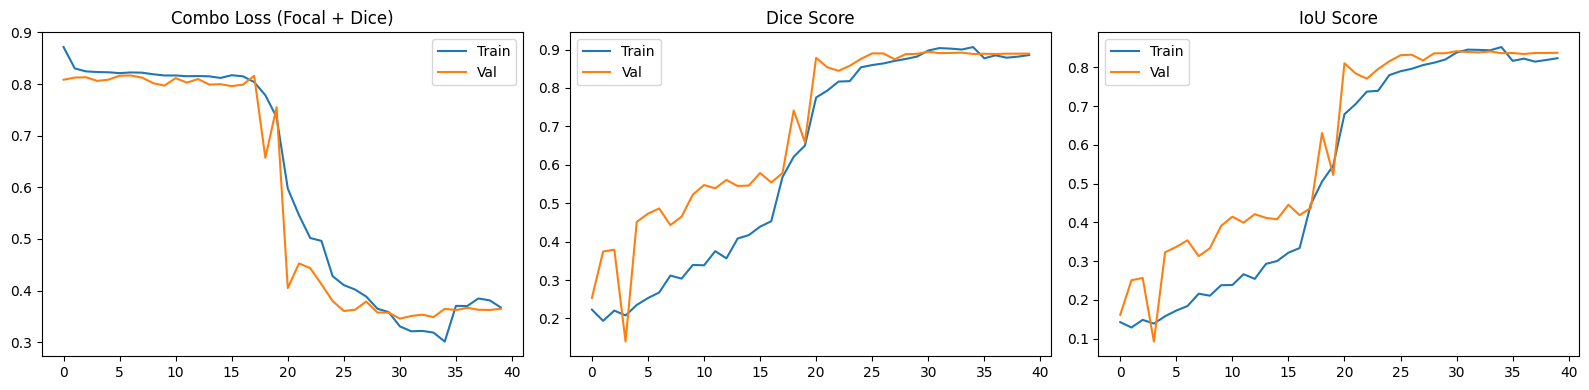

In [11]:
def plot_history(hist):
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    
    axes[0].plot(hist["train_loss"], label="Train")
    axes[0].plot(hist["val_loss"], label="Val")
    axes[0].set_title("Combo Loss (Focal + Dice)"); axes[0].legend()
    
    axes[1].plot(hist["train_dice"], label="Train")
    axes[1].plot(hist["val_dice"], label="Val")
    axes[1].set_title("Dice Score"); axes[1].legend()
    
    axes[2].plot(hist["train_iou"], label="Train")
    axes[2].plot(hist["val_iou"], label="Val")
    axes[2].set_title("IoU Score"); axes[2].legend()
    
    plt.tight_layout()
    plt.show()

plot_history(history)

In [12]:
model.load_state_dict(torch.load("best_model.pt", weights_only=True))

def evaluate_dataset(loader, dataset_name):
    model.eval()
    raw_dices, raw_ious = [], []
    pp_dices, pp_ious = [], []
    
    with torch.no_grad():
        for imgs, masks in loader:
            imgs, masks = imgs.to(device), masks.to(device)
            with torch.amp.autocast('cuda'):
                logits = model(imgs)
            
            rd, rj = evaluate_metrics(logits, masks, apply_pp=False)
            pd, pj = evaluate_metrics(logits, masks, apply_pp=True)
            
            raw_dices.append(rd)
            raw_ious.append(rj)
            pp_dices.append(pd)
            pp_ious.append(pj)
            
    print(f"========== {dataset_name} ==========")
    print(f"RAW PREDICTIONS -> Dice: {np.mean(raw_dices):.4f} | IoU: {np.mean(raw_ious):.4f}")
    print(f"POST-PROCESSED  -> Dice: {np.mean(pp_dices):.4f} | IoU: {np.mean(pp_ious):.4f}\n")

evaluate_dataset(kvasir_test_loader, "Kvasir-SEG Test (Internal)")
evaluate_dataset(cvc_test_loader, "CVC-ClinicDB Test (External)")

========== Kvasir-SEG Test (Internal) ==========
RAW PREDICTIONS -> Dice: 0.8960 | IoU: 0.8317
POST-PROCESSED  -> Dice: 0.8960 | IoU: 0.8318

========== CVC-ClinicDB Test (External) ==========
RAW PREDICTIONS -> Dice: 0.8542 | IoU: 0.7803
POST-PROCESSED  -> Dice: 0.8542 | IoU: 0.7803

